### Your Task
- Exploratory Data Analysis
    - Use pandas to load the dataset and examine the first few rows.
    - Check and handle the missing values.
    - Drop any unnecessary column
    - Create a Countplot to display diagnosis from magma

- Data Preprocessing, Building Models and Evaluation :
    - counts of unique rows in the ‘diagnosis’ column
    - map categorical values to numerical values
    - Splitting the data into train and test
    - Implement logistic regression and print the accuracy.
    - Implement K Nearest Neighbours and print the accuracy.
    - Implement Random Forests and print the accuracy.
    - Implement Support Vector Machines (SVM) and print the accuracy.
    - Which is the best model ?


### Solution

In [1]:
# basic setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv("data/data_breast_cancer.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.shape

(569, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
# drop unnecessary columns
df = df.drop(labels=['id', 'Unnamed: 32'], axis=1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


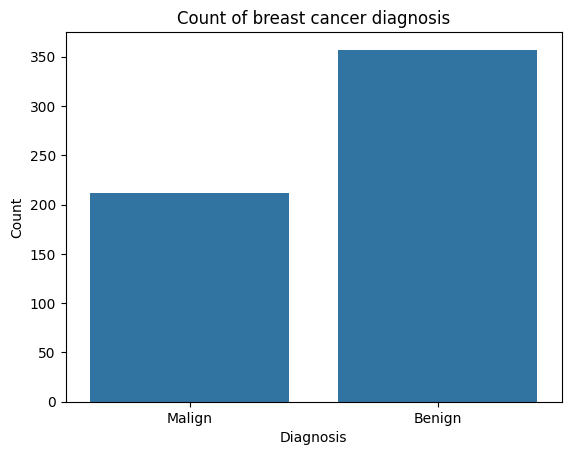

In [6]:
# create countplot for breast cancer diagnosis
sns.countplot(data=df,x='diagnosis')
plt.title('Count of breast cancer diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
# Customize tick marks
plt.xticks(['M', 'B'], ['Malign', 'Benign'])
plt.show()


In [7]:
# target variable
diag_vals = df['diagnosis'].unique().tolist()
print(f'Possible diagnosis before transformation: {diag_vals}')

# map str to int
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print(f'Possible diagnosis after transformation: {df['diagnosis'].unique().tolist()}')

Possible diagnosis before transformation: ['M', 'B']
Possible diagnosis after transformation: [1, 0]


In [8]:
# fix target for prediction
target = "diagnosis"

# split features and target
X = df.drop(columns=target)
y = df[target]

# train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y)

In [9]:
# create logistic regression model
model = LogisticRegression(max_iter=10000)

# train the model
model.fit(X_train, y_train)

# predict the outcome
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.2f}\n")
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.94

              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



**Observation**: The logistic regression model achieved an accuracy of 0.94, indicating strong predictive performance. Precision for the positive class is 0.97, meaning that when the model predicts cancer it is usually correct. Recall is 0.86, meaning that about 14% of cancer cases are missed. In medical applications recall is particularly important, since false negatives are more dangerous than false positives.

In [10]:
# scale the training and test dataset features so that larger numerical ranges do not dominate the distance metric
# Create a scaler
scaler = StandardScaler()

# Fit the scaler on training data
scaler.fit(X_train)

# Transform the data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# create a KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# train the model
knn.fit(X_train_scaled, y_train)

# predict the outcome
y_pred = knn.predict(X_test_scaled)

print(f"KNN Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

KNN Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



**Observation**: The K-Nearest Neighbors model achieved an accuracy of 0.96, outperforming logistic regression. Precision for the cancer class remained high (0.97), while recall improved from 0.86 to 0.90, meaning fewer cancer cases were missed. Because KNN can capture nonlinear relationships between features, it can better adapt to the structure of the dataset than logistic regression.